In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
%matplotlib inline
import h5py
from sklearn.decomposition import PCA
from getdist import MCSamples, plots
from scipy.stats import norm
from numpy import linalg as la

plt.rcParams['figure.figsize'] = (3.5, 2.5)

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.size'] = 15

colors1 = [
    "#1b5f6f",  # dark teal
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#882255",  # wine
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#999999",  # grey
    "#117733",  # dark green
]

In [2]:
path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'

survey = 'roman'

class SURVEY:
    def __init__(self,survey):
        self.survey = survey

    # Global parameters
    def nz_params(self):
        if self.survey == 'des':
            Nz = 299 #len(z)
            Nt = 4
        elif self.survey == 'roman':   
            Nz = 46 #len(z)
            Nt = 9
        return Nz,Nt

    # Auxiliary functions
    def get_nzs(self):
        Nz,Nt = self.nz_params()
        if self.survey == 'des':
            nz = f'{path}/roman_nz_realizations/Fisher_matrix/Tz_realizations_WZ_bq_pile3_0d01.npy' # shared by Boyan Yin
            nz = np.load(nz)             ## shape = (10095, 4, 300) = (Ns, Nt, Nz) = (# of simulations, # of tomo bins, # of redshift)
            nz = nz[:,:,1:]              ## shape = (10095, 4, 299) | (first :) => all 10095 simulations, (second :) => all 4 tomo bins, (third ,1:) => all redshift bins except the first where nz is 0.0.
            Ns = np.shape(nz)[0]         ## Number of simulations: 10095
            nz = nz.reshape(Ns, Nt * Nz) ## shape = (10095, 1196) = (Ns, Nt*Nz)
            min_z   = 0.01
            max_z   = 3
            delta_z = (max_z - min_z) / Nz
            zbins   = np.arange(min_z,max_z+delta_z,delta_z)
            z  = zbins[:-1]+(zbins[1]-zbins[0])/2.
            return z, nz

        elif self.survey == 'roman':
            sc = 'sc3b_d4'
            nz = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r') # shared by Boyan Yin
            z = np.array(nz['zbinsc'])
            return z, nz

    def cov_of_ndiff(self,use_r=True):
        Nz,Nt = self.nz_params()
        z,nz = self.get_nzs()

        if self.survey == 'roman':
            # Never use r=10^6 on login node.
            if use_r:
                r = 500 # hundreds/thousands out of 1M realizations
                np.random.seed(42)
                sims_indexes = np.random.randint(1, 10**6 + 1, size=r)
                tot = len(sims_indexes)    

                rows = []
                print(f"Total: {r}. Processing index:")
                for jj, j in enumerate(sims_indexes):
                    row = []
                    for i in range(Nt):
                        norm = np.trapz(y=nz[f'bin{i}'][j], x=z)
                        normalized = nz[f'bin{i}'][j] / norm
                        row.append(normalized)
                    #row shape after appending all bins: (Nt,Nz)
                    print(jj, end=' ')
                    rows.append(np.hstack(row))
                #rows shape after appending all realizations: (tot,Nt*Nz)
                nz = np.vstack(rows) # (tot,Nt*Nz)
                nbar = np.mean(nz,axis=0)
                ndiff = nz - nbar
                Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff / sample size - 1
            else:
                # Use Cn from all 10^6
                Cn = np.load(f'{path}/n_nbar_ndiff_covndiff/cov_ndiff_sc1b_d4.npy') #TODO: path changed    
        elif self.survey == 'des':
            ### nzs for DES already are normalized
            ### set parameter below to True if you want to check
            check_des_nz_normalization = False
            if check_des_nz_normalization:
                rows = []
                for j in range(10095):
                    row = []
                    for i in range(Nt):
                        start, end = Nz*i, Nz*(i+1)
                        norm = np.trapz(y=nz[j,start:end], x=z)
                        normalized = nz[j,start:end] / norm
                        row.append(normalized)
                    rows.append(np.hstack(row))
                nz = np.vstack(rows)

            nbar = np.mean(nz,axis=0)
            ndiff = nz - nbar
            Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff / sample size - 1
        if use_r and self.survey=='roman':
            return Cn, ndiff
        elif use_r==False and (self.survey=='roman' or self.survey=='des'):
            return Cn
        elif self.survey=='des':
            return Cn

    # Unweighted PCA    
    def pcs(self,method='eig',use_r=True):
        Nz,Nt = self.nz_params()
        Nd = Nz*Nt
        if use_r and self.survey=='roman':
            Cn,_ = self.cov_of_ndiff()
        elif use_r==False and self.survey=='roman':
            # Ignore Cn from r (hundreds or thousands) realizations, use Cn from all 10^6.
            Cn = np.load(f'{path}/n_nbar_ndiff_covndiff/cov_ndiff_sc1b_d4.npy') #TODO: path changed
        else:
            Cn = self.cov_of_ndiff()
        Cn = 0.5*(Cn + Cn.T)
        if method == 'eig':
            eigvals, eigvecs = np.linalg.eig(Cn)
        elif method == 'eigh':
            eigvals, eigvecs = np.linalg.eigh(Cn)
        elif method == 'svd':    
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'sklearn':
            pca = PCA()
            pca.fit(Cn)
            eigvecs, eigvals = pca.components_, pca.singular_values_
            explained_variance = pca.explained_variance_
            explained_variance_ratio = pca.explained_variance_ratio_
        ######
        if method != 'sklearn':
            eigvals = np.real(eigvals)
            eigvecs = np.real(eigvecs)
            idx     = np.argsort(eigvals)[::-1] # 1. Get indices to sort eigenvalues in descending order
            eigvals = eigvals[idx]              # 2. Sort eigenvalues (largest to smallest)
            eigvals = np.maximum(0,eigvals)     # 3. Clamp any small negative eigenvalues to 0 (often due to numerical errors)
            eigvecs = eigvecs[:, idx]           # 4. Reorder columns of eigenvectors to match sorted eigenvalues
            return eigvecs, eigvals
        elif method == 'sklearn':
            return eigvecs.T, eigvals, explained_variance,explained_variance_ratio 
            
    # Credit: Gary M. Bernstein
    def nearestPD(self,A):
        """Find the nearest positive-definite matrix to input
        A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
        credits [2].
        [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd
        [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
        matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
        """
        B = (A + A.T) / 2
        _, s, V = np.linalg.svd(B)
        H = np.dot(V.T, np.dot(np.diag(s), V))
        A2 = (B + H) / 2
        A3 = (A2 + A2.T) / 2
        if self.isPD(A3):
            return A3
        spacing = np.spacing(np.linalg.norm(A))
        I = np.eye(A.shape[0])
        k = 1
        while not self.isPD(A3):
            mineig = np.min(np.real(np.linalg.eigvals(A3)))
            A3 += I * (-mineig * k**2 + spacing)
            k += 1
        return A3

    def isPD(self,B):
        """Returns true when input is positive-definite, via Cholesky"""
        try:
            _ = np.linalg.cholesky(B)
            return True
        except np.linalg.LinAlgError:
            return False              
    
    def getModes(self,D, Cn, chisq_threshold=0.1):
        '''Calculate the compression matrix from n to u and the
        modes U that multiply each U.  
        Parameters:
        `D`:      The matrix J^T C_c^{-1} J, where C_c is the covariance
                matrix of the observables c, and J is the Jacobian dc/dn,
                shape=(N,N)
        `Cn`:     Covariance matrix of the n(z) parameter vector n, shape=(N,N)
        `chisq_threshold`:  Your desired upper bound for the mean error in chisq
                resulting from the compression.
        Returns:
        `X`:      The compression matrix, u = X @ n, shape=(nModes,N).  The
                covariance matrix of the u's will be the identity.
        `U`:      The decoding matrix, n' = U @ u, shape=(N,nModes)
        `dchisq`: The mean chisq shift generated by each mode, shape=(nModes)
        `resid`:  Mean amount of chisq shift caused by compression.

        You can safely use fewer than `nModes` of the returned X and U if you 
        think the discarded `dchisq` values are small enough.'''

        thr = 1e-25     # Dynamic range threshold for eigenvalues

        # Symmetrize and sqrt D
        D = 0.5*(D + D.T)
        Dval, Dvec = np.linalg.eigh(D)
        # Any negatives are numerical problems
        Dval = np.maximum(0., Dval)

        # And Cn
        Cnval, Cnvec = np.linalg.eigh(Cn)
        Cnval = np.maximum(0., Cnval)

        # Build the keystone matrix and its SVD
        M = np.einsum('i,ji,jk,k->ik',np.sqrt(Cnval), Cnvec, Dvec, np.sqrt(Dval))
        Um,s,Vmt = np.linalg.svd(M)

        # Sort SV's and throw away unwanted ones
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
                                            
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        Um = Um[:,keep]
        Vm = Vmt.T[:,keep]
        s = s[keep]

        # Build the encoder
        tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
        X = np.einsum('ij,i,ki->jk',Um, tmp, Cnvec)  # X is (M,N)
        # And the decoder
        tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
        U = np.einsum('ji,i,ik,k->jk',Dvec, tmp, Vm,s) # Vm s
        
        return X, U, s*s, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M

# Unweighted PCA

## Roman case  

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{46}],[\text{PC}^1_{47},\text{PC}^1_{48},\cdots,\text{PC}^1_{92}],6\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{413},\cdots,\text{PC}^1_{414}]\Big]$

In [11]:
roman_obj = SURVEY('roman')
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()

use_r=False

eig_vecs, eig_vals = roman_obj.pcs('eig',use_r=use_r)
eih_vecs, eigh_vals = roman_obj.pcs('eigh',use_r=use_r)
svd_vecs, svd_vals = roman_obj.pcs('svd',use_r=use_r)
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = roman_obj.pcs('sklearn',use_r=use_r)

/tmp/ipykernel_3274958/3046020584.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

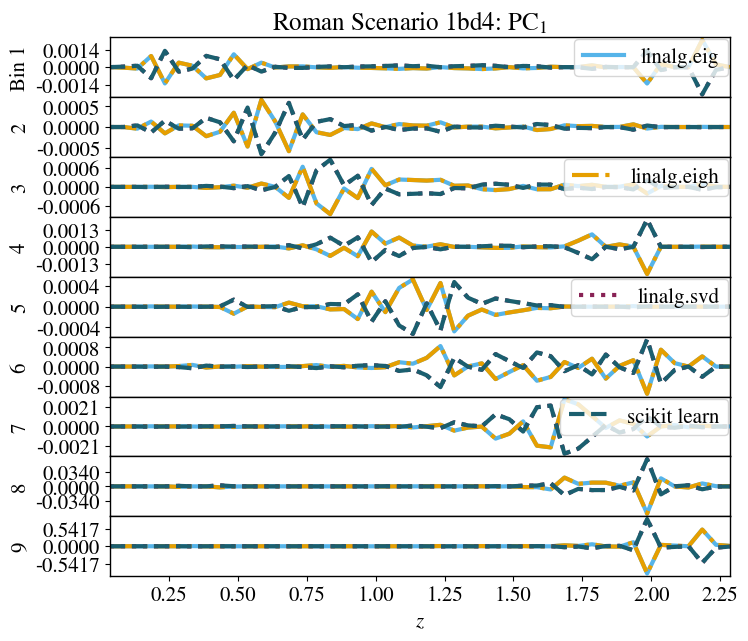

In [8]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2.5
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.plot(z, eig_vecs[start:end, pci],c=colors[0],lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c=colors[1],lw=3, ls='-.', label='linalg.eigh' if k==2 else None)
    ax.plot(z, svd_vecs[start:end, pci],c=colors[2],lw=3, ls=':', label='linalg.svd' if k==4 else None)
    ax.plot(z, skl_vecs[start:end, pci],c=colors[3],lw=3, ls='--' , label='scikit learn' if k==6 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [1,3,5,7,8]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", y=0.92);

### Test 2 - Pick up the first three PCs and plot their slices across the tomographic bins

/tmp/ipykernel_3274958/3743058113.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

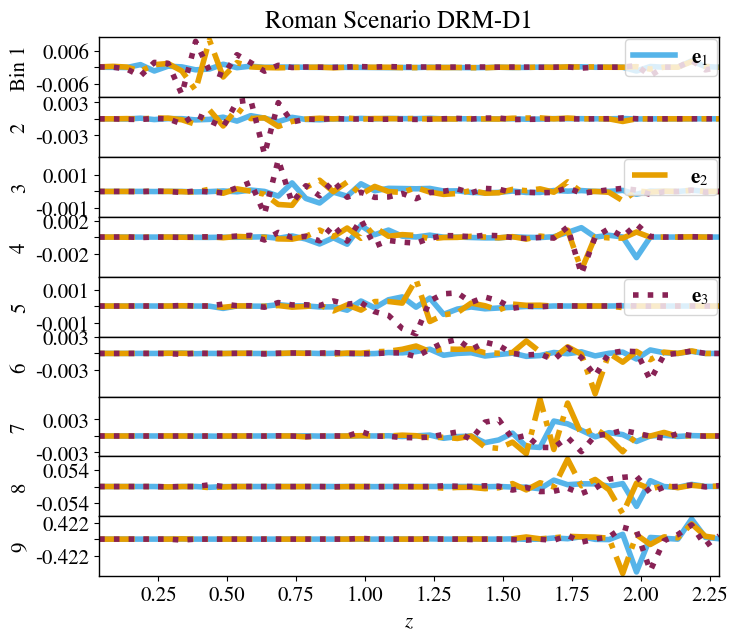

In [9]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = eig_vecs[start:end, pcis[0]]
    e2 = eig_vecs[start:end, pcis[1]]
    e3 = eig_vecs[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 2, 4]
    ax.plot(z, e1, c=colors[0], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls=':', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(9) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario DRM-D1", y=0.92);
plt.savefig('test.pdf')

### Test 3 - Plot the eigenvalues
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The eigenvalues/singular values are the same.

Text(0.5, 0.98, 'Roman Scenario 1bd4')

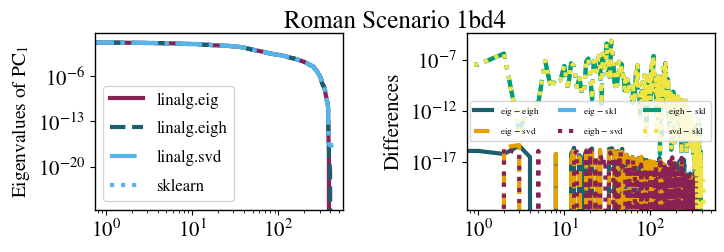

In [10]:
Ms = list(range(Nz*Nt))
colors=["#882255","#1b5f6f",'#56B4E9',"#56B4E9"]
fig, axes = plt.subplots(1, 2, figsize=(8, 2.3), sharex=True,gridspec_kw={'wspace':.5, 'hspace':1.0})

axes[0].plot(Ms,eig_vals ,c=colors[0],lw=3, ls='-' ,label='linalg.eig')
axes[0].plot(Ms,eigh_vals,c=colors[1],lw=3, ls='--',label='linalg.eigh')
axes[0].plot(Ms,svd_vals ,c=colors[2],lw=3, ls='-.',label='linalg.svd')
axes[0].plot(Ms,skl_vals ,c=colors[3],lw=3, ls=':' ,label='sklearn')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(rf'Eigenvalues of PC$_1$',fontsize=14)
axes[0].legend(loc='best',fontsize=12)

axes[1].loglog(Ms,eig_vals-eigh_vals,c=colors1[0],lw=3, ls='-' ,label=r'eig $-$ eigh')
axes[1].loglog(Ms,eig_vals-svd_vals, c=colors1[1],lw=3, ls='--',label=r'eig $-$ svd')
axes[1].loglog(Ms,eig_vals-skl_vals, c=colors1[2],lw=3, ls='-.',label=r'eig $-$ skl')

axes[1].loglog(Ms,eigh_vals-svd_vals,c=colors1[3],lw=3, ls=':' ,label=r'eigh $-$ svd')
axes[1].loglog(Ms,eigh_vals-skl_vals,c=colors1[4],lw=3, ls='-.',label=r'eigh $-$ skl')

axes[1].loglog(Ms,svd_vals-skl_vals, c=colors1[5],lw=3, ls=':',label=r'svd $-$ skl')
axes[1].legend(loc='center',fontsize=6.6,ncol=3)
axes[1].set_ylabel(rf'Differences')
fig.suptitle('Roman Scenario 1bd4')

### Test 4 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758). However, if we force $F=I$, then both methods possoes the same eigenvalue, while the eigenvector differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigenvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eigenvectors differ by a scaling factor of $\Lambda_n^{1/2}$:  
The decoding matrix (eq 19/20 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [64]:
use_r=False
if use_r:
    Cn,ndiff = roman_obj.cov_of_ndiff()
else:    
    Cn = roman_obj.cov_of_ndiff(use_r=use_r)
D = np.identity(Cn.shape[0])

if not roman_obj.isPD(D):
    print('fixing cov')
    D=roman_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(D,Cn,chisq_threshold=0);

UnboundLocalError: local variable 'Cn' referenced before assignment

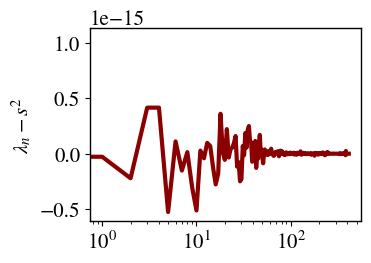

In [12]:
plt.plot(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.xscale('log')
plt.ylabel(r'$\lambda_n-s^2$');

/tmp/ipykernel_3274958/1062677139.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

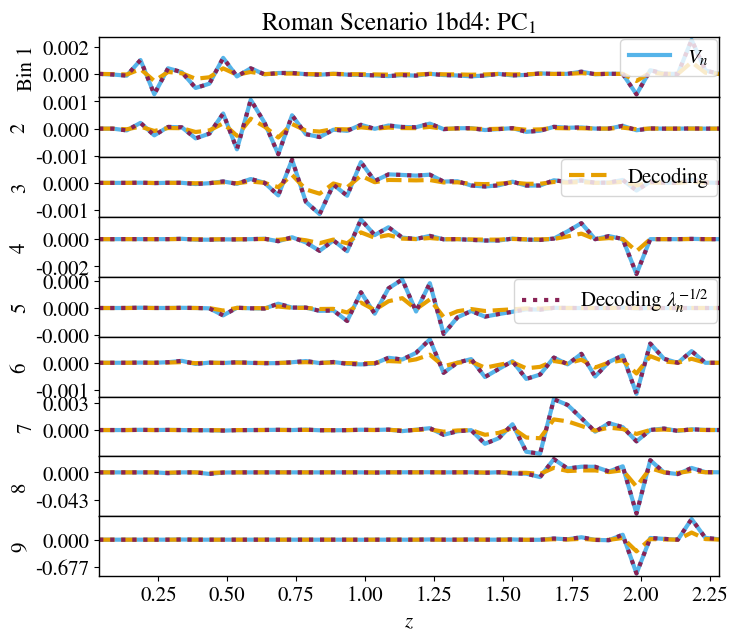

In [13]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix  = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0
ks = [0,2,4]
for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==ks[0] else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==ks[1] else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls=':', label=r'Decoding $\lambda_n^{-1/2}$' if k==ks[2] else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", y=0.92);

## DES case

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{299}],[\text{PC}^1_{300},\text{PC}^1_{301},\cdots,\text{PC}^1_{598}],1\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{898},\cdots,\text{PC}^1_{1196}]\Big]$

In [15]:
des_obj = SURVEY('des')
Nz,Nt = des_obj.nz_params()
z,nz = des_obj.get_nzs()

eig_vecs, eig_vals = des_obj.pcs('eig')
eih_vecs, eigh_vals = des_obj.pcs('eigh')
svd_vecs, svd_vals = des_obj.pcs('svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = des_obj.pcs('sklearn')

<Figure size 350x250 with 0 Axes>

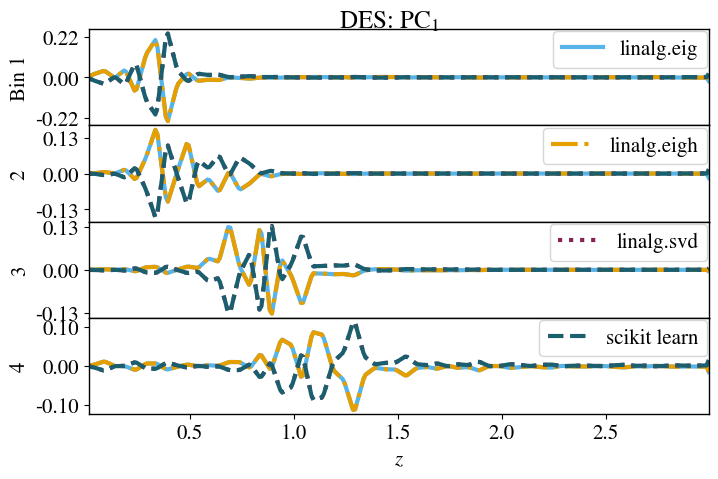

In [21]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.plot(z, eig_vecs[start:end, pci],c=colors[0],lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c=colors[1],lw=3, ls='-.', label='linalg.eigh' if k==1 else None)
    ax.plot(z, svd_vecs[start:end, pci],c=colors[2],lw=3, ls=':', label='linalg.svd' if k==2 else None)
    ax.plot(z, skl_vecs[start:end, pci],c=colors[3],lw=3, ls='--' , label='scikit learn' if k==3 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_{{{pci+1}}}$", y=0.92);

### Test 2 - Pick up the first three PCs and plot their slices across the tomographic bins

/tmp/ipykernel_3510962/3076853019.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

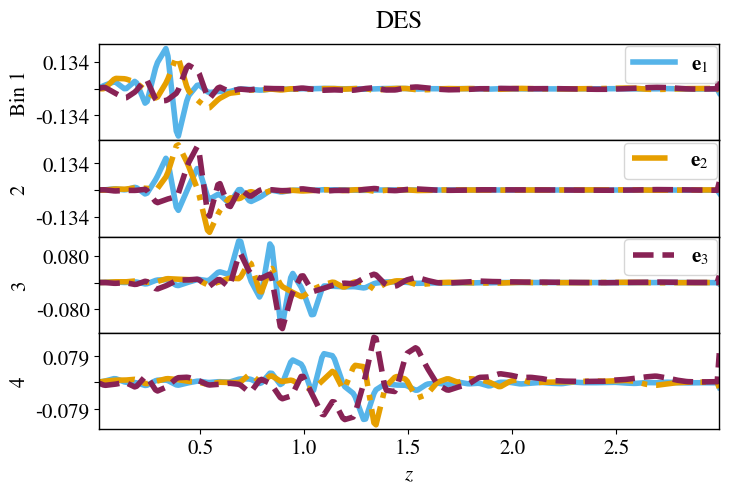

In [22]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = eig_vecs[start:end, pcis[0]]
    e2 = eig_vecs[start:end, pcis[1]]
    e3 = eig_vecs[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 1, 2]
    ax.plot(z, e1, c=colors[0], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls='--', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES", y=0.95);

### Test 3 - Plot the eigenvalues
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The eigenvalues/singular values are the same.

Text(0.5, 0.98, 'DES')

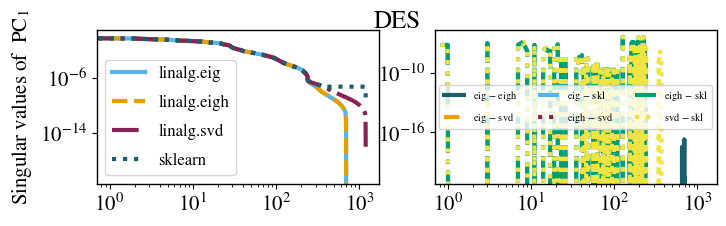

In [23]:
Ms = list(range(Nz*Nt))

fig, axes = plt.subplots(1, 2, figsize=(8, 2), sharex=True)

axes[0].plot(Ms,eig_vals ,c=colors[0],lw=3, ls='-' ,label='linalg.eig')
axes[0].plot(Ms,eigh_vals,c=colors[1],lw=3, ls='--',label='linalg.eigh')
axes[0].plot(Ms,svd_vals ,c=colors[2],lw=3, ls='-.',label='linalg.svd')
axes[0].plot(Ms,skl_vals ,c=colors[3],lw=3, ls=':' ,label='sklearn')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(rf'Singular values of  PC$_1$')
axes[0].legend(loc='best',fontsize=12)

axes[1].loglog(Ms,eig_vals-eigh_vals,c=colors1[0],lw=3, ls='-' ,label=r'eig $-$ eigh')
axes[1].loglog(Ms,eig_vals-svd_vals, c=colors1[1],lw=3, ls='--',label=r'eig $-$ svd')
axes[1].loglog(Ms,eig_vals-skl_vals, c=colors1[2],lw=3, ls='-.',label=r'eig $-$ skl')

axes[1].loglog(Ms,eigh_vals-svd_vals,c=colors1[3],lw=3, ls=':' ,label=r'eigh $-$ svd')
axes[1].loglog(Ms,eigh_vals-skl_vals,c=colors1[4],lw=3, ls='-.',label=r'eigh $-$ skl')

axes[1].loglog(Ms,svd_vals-skl_vals, c=colors1[5],lw=3, ls=':',label=r'svd $-$ skl')
axes[1].legend(loc='center',fontsize=7.5,ncol=3)
fig.suptitle('DES')

### Test 4 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758). However, if we force $F=I$, then both methods possoes the same eigenvalue, while the eigenvector differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigenvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eigenvectors differ by a scaling factor of $\Lambda_n^{1/2}$:  
The decoding matrix (eq 19/20 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [24]:
Cn = des_obj.cov_of_ndiff()
D = np.identity(Cn.shape[0])

if not des_obj.isPD(D):
    print('fixing cov')
    D=des_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(D,Cn,chisq_threshold=0);

/tmp/ipykernel_3510962/129678367.py:216: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


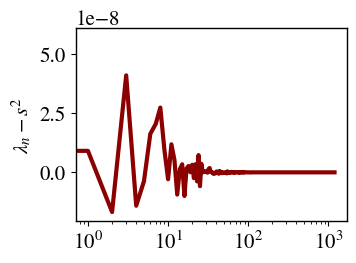

In [25]:
plt.plot(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.xscale('log')
plt.ylabel(r'$\lambda_n-s^2$');

/tmp/ipykernel_3510962/1309737692.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

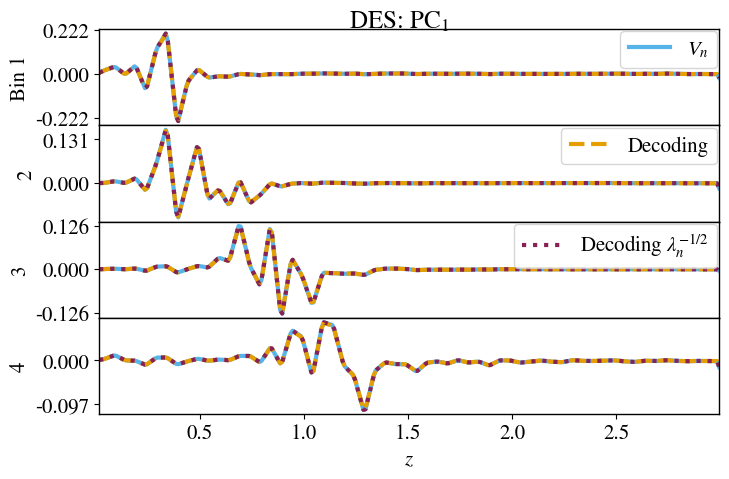

In [26]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix  = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

ks = [0,1,2]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==ks[0] else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==ks[1] else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls=':', label=r'Decoding $\lambda_n^{-1/2}$' if k==ks[2] else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_1$", y=0.92);

# Lets plot how the PCs's amplitudes are distributed  
The amplitudes $\alpha_i$'s are just the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

## Roman

In [3]:
use_r=True # ndiff is (10^6,414), so we must set use_r=True

roman_obj = SURVEY('roman')
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()

if use_r:
    Cn,ndiff = roman_obj.cov_of_ndiff()
else:    
    Cn = roman_obj.cov_of_ndiff(use_r=use_r)
D = np.identity(Cn.shape[0])

if not roman_obj.isPD(D):
    print('fixing cov')
    D=roman_obj.nearestPD(D)

eih_vecs, eigh_vals = roman_obj.pcs('eigh',use_r=use_r)
X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(D,Cn,chisq_threshold=0);

Total: 500. Processing index:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 

/tmp/ipykernel_3550436/3155315877.py:216: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


In [4]:
alphas = ndiff @ eih_vecs

alphas.shape
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]

chains = MCSamples(samples=alphas,names=names,labels=labels)

nEig:  414
Removed no burn in


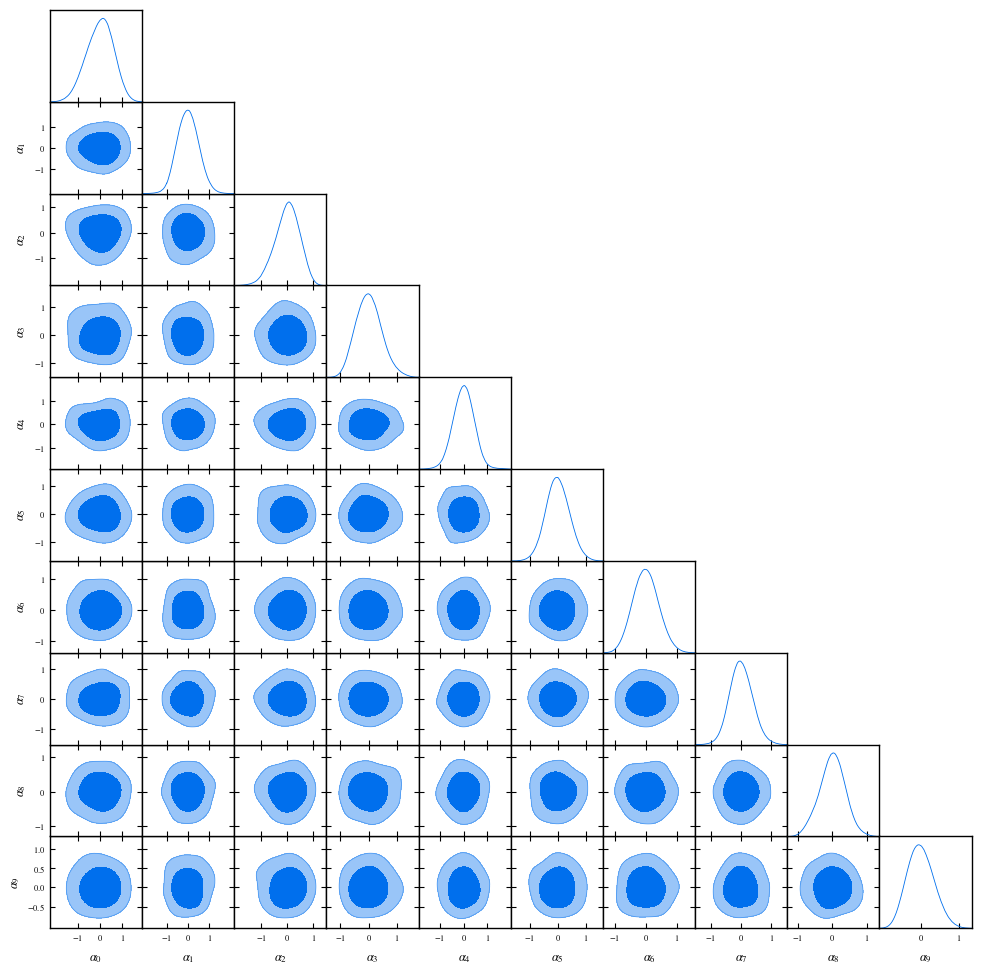

In [10]:
g = plots.get_subplot_plotter(subplot_size=1)
g.triangle_plot(chains,["alpha%s" %i for i in range(10)],filled=True)

# DES 

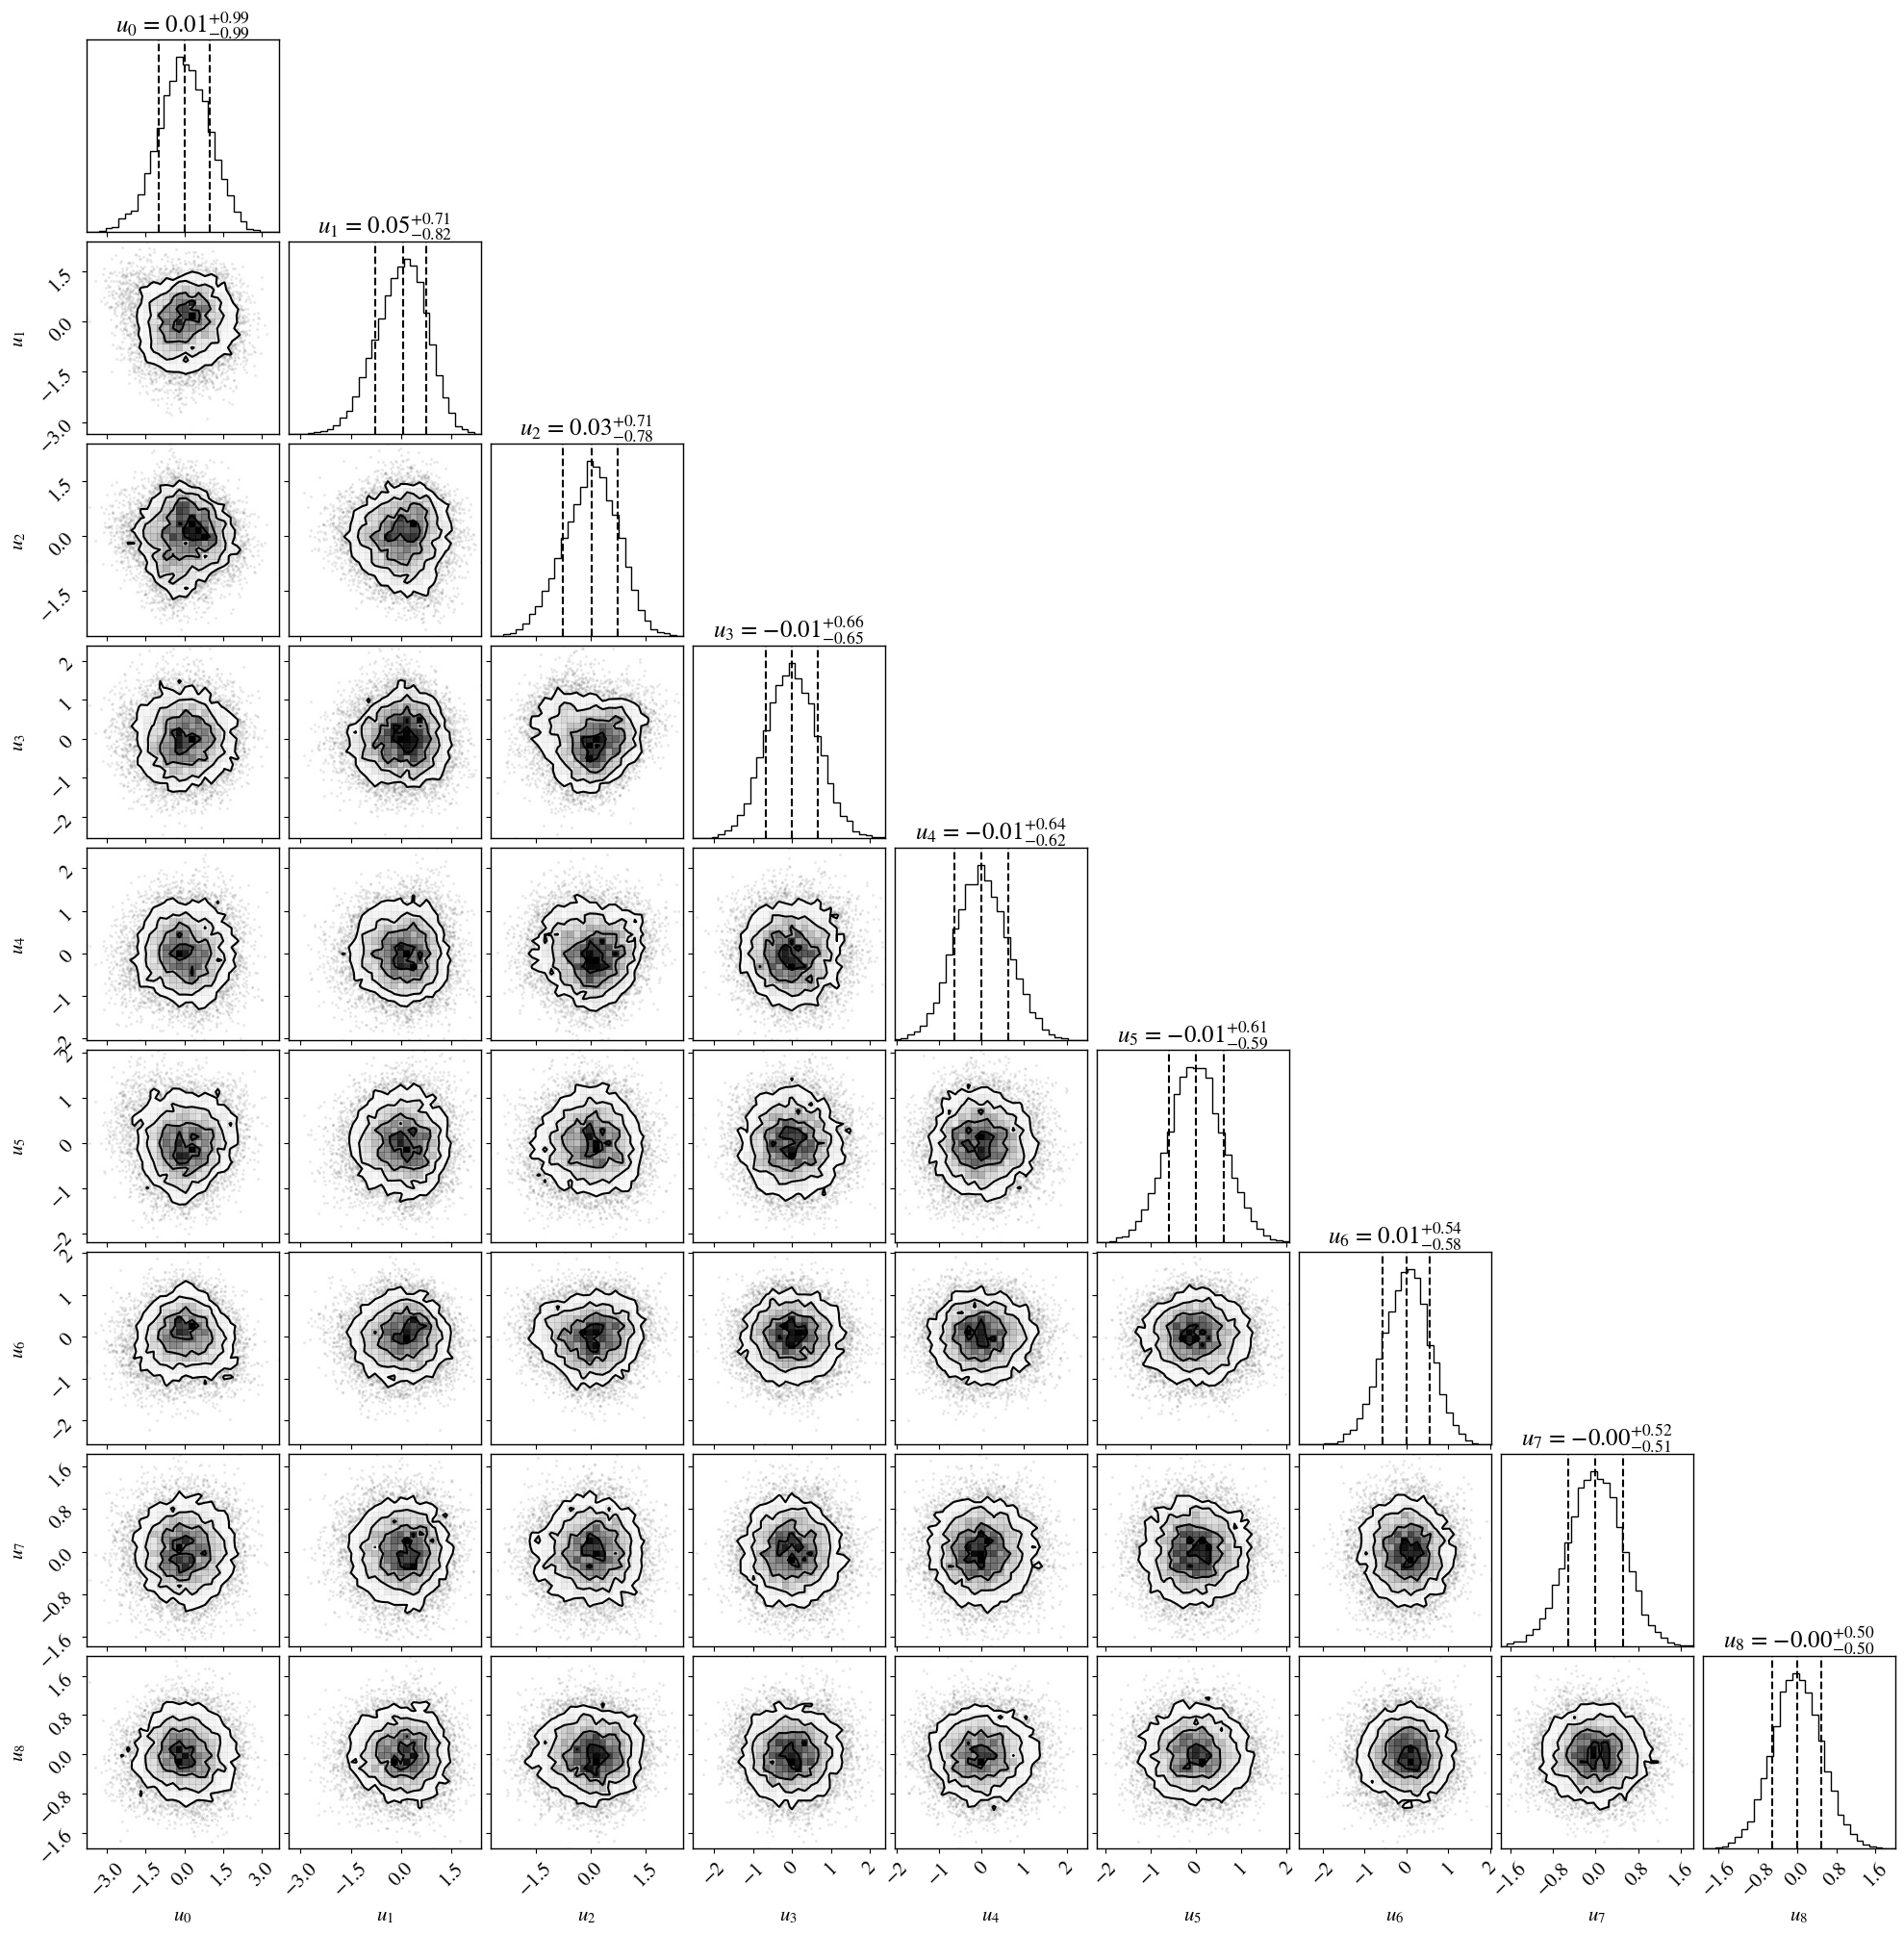

In [93]:
import corner
%matplotlib inline

# Labels des paramètres (ajustez si vous avez plus de corrélations)
n_max = 9
labels = [f"$u_{i}$" for i in range(n_max)]

figure = corner.corner(
    alphas[:,:n_max],
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    bins=30,  # Taille des bins pour l'histogramme
    title_fmt=".2f",
    # title_kwargs={"fontsize": 12},
    # label_kwargs={"fontsize": 14}
)

# Lets check the function that forward the PCA model of $n(z)$ to CoCoA  
More specifically, to _cosmolike_prototype_interface.py.  
CoCoA needs nz in the form [z, nz_tomo_1, nz_tomo_2, ..., nz_tomo_n] where nz_tomo_i is the nz in the ith tomographic bin.  
The PCs, by construction, are obtained from the concatenation across the tomographic bins of the array nz-nbar    
The PCs are saved in a table with shape (len(PC), # PCs) = (len(z) * Ntomo, len(z) * Ntomo)  
The model: $n(z) = \bar{n}(z)+\alpha_1\cdot\mathbf{PC}_1+\alpha_2\cdot\mathbf{PC}_2+\cdots+\alpha_n\cdot\mathbf{PC}_n$  

In [182]:
nbar_fake = np.array([[1,2,3,4],  [5,6,7,8],   [9,10,11,12]]).T  # 3 tomo bins, 4 redshift bins as provided to cocoa
pcs_fake = np.array([[1,2,3,4,     5,6,7,8,     9,10,11,12],     # PC_1
                     [13,14,15,16, 17,18,19,20, 21,22,23,24]]).T # PC_2

npcs = 2 
U = pcs_fake
params_values = {"fake_alpha_1":2,"fake_alpha_2":1} # fake params from cobaya
alphas = np.array([params_values.get("fake_alpha_"+str(i+1)) for i in range(npcs)])

print(f"{'PC_1':>5} {'PC_2':>5} {'':>1} {'<nz>_1':>7}{'<nz>_2':>7}{'<nz>_3':>7}")

# Max rows needed: max(12 for PCs, 4 for nbar_fake)
max_rows = max(len(pcs_fake), nbar_fake.shape[0])

for i in range(max_rows):
    pc1 = pcs_fake[i,0] if i < len(pcs_fake) else ''
    pc2 = pcs_fake[i,1] if i < len(pcs_fake) else ''
    nz1 = nbar_fake[i,0] if i < nbar_fake.shape[0] else ''
    nz2 = nbar_fake[i,1] if i < nbar_fake.shape[0] else ''
    nz3 = nbar_fake[i,2] if i < nbar_fake.shape[0] else ''
    print(f"{pc1:5} {pc2:5} {nz1:6} {nz2:6} {nz3:6}")

 PC_1  PC_2    <nz>_1 <nz>_2 <nz>_3
    1    13      1      5      9
    2    14      2      6     10
    3    15      3      7     11
    4    16      4      8     12
    5    17                     
    6    18                     
    7    19                     
    8    20                     
    9    21                     
   10    22                     
   11    23                     
   12    24                     


In [173]:
alphas_x_U = (alphas * U)
correction = (alphas * U).sum(axis=1)

print(f"{'α1·PC1':>5} {'α2·PC2':>5}  {'':>2} {'α1·PC1 + α2·PC2':>9}")

for i in range(len(alphas_x_U)):
    α1_x_pc1 = alphas_x_U[i,0] 
    α2_x_pc2 = alphas_x_U[i,1] 
    corr = correction[i] 
    print(f"{α1_x_pc1:5} {α2_x_pc2:5} {corr:15}")

α1·PC1 α2·PC2     α1·PC1 + α2·PC2
    2    13              15
    4    14              18
    6    15              21
    8    16              24
   10    17              27
   12    18              30
   14    19              33
   16    20              36
   18    21              39
   20    22              42
   22    23              45
   24    24              48


In [174]:
s = nbar_fake[:,:].shape # in the code we do self.nbar[:,1:].shape to not cout the redshift column, here isn't necessary
print(s)

(4, 3)


In [175]:
nz_model = nbar_fake[:,:].T.flatten() + correction # in the code we do self.nbar[:,1:].T.flatten() to not count the redshift column, here isn't necessary
nz_model_2 = nz_model.reshape(s[::-1]).T
print('STEP 1: <nbar>:\n',nbar_fake,'\n')
print('STEP 2: <nbar> flattened:',nbar_fake[:,:].T.flatten(),'\n')
print('STEP 3: correction:', correction,'\n')
print('STEP 4: <nbar> flattened + correction:',nz_model,'\n')
print('STEP 5: restore nz in CoCoA table-like format:\n',nz_model_2)

STEP 1: <nbar>:
 [[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]] 

STEP 2: <nbar> flattened: [ 1  2  3  4  5  6  7  8  9 10 11 12] 

STEP 3: correction: [15 18 21 24 27 30 33 36 39 42 45 48] 

STEP 4: <nbar> flattened + correction: [16 20 24 28 32 36 40 44 48 52 56 60] 

STEP 5: restore nz in CoCoA table-like format:
 [[16 32 48]
 [20 36 52]
 [24 40 56]
 [28 44 60]]


# Tests and working in progress - ignore codes from this point

In [186]:
n_pcs = 2
n_bins = 3
n_z = 4

pcs_reshaped = pcs_fake.reshape(n_pcs, n_bins, n_z)
pcs_reshaped = pcs_reshaped.transpose(0,2,1)  # (n_pcs, n_z, n_bins)
print(pcs_fake)
print(pcs_reshaped)
alphas = np.array([params_values.get(f"fake_alpha_{i+1}") for i in range(n_pcs)])
print(alphas)
pc_sum = np.sum([alpha * pcs_reshaped[i] for i, alpha in enumerate(alphas)], axis=0)
nz_modified = nbar_fake + pc_sum
print(nz_modified)
print(nz_model_2)

[[ 1 13]
 [ 2 14]
 [ 3 15]
 [ 4 16]
 [ 5 17]
 [ 6 18]
 [ 7 19]
 [ 8 20]
 [ 9 21]
 [10 22]
 [11 23]
 [12 24]]
[[[ 1  3  5]
  [13 15 17]
  [ 2  4  6]
  [14 16 18]]

 [[ 7  9 11]
  [19 21 23]
  [ 8 10 12]
  [20 22 24]]]
[2 1]
[[10 20 30]
 [47 57 67]
 [15 25 35]
 [52 62 72]]
[[16 32 48]
 [20 36 52]
 [24 40 56]
 [28 44 60]]


In [13]:
def forward_pca(nz_fid,params_values,survey,photoz_pc_file,npc):
    
    if npc == 0:
        return nz_fid

    elif npc > 0:
        U = photoz_pc_file[:,:npc] # Here is not a file, but in CoCoA is. We keep the notation.
        alphas_vals = np.array([params_values.get(survey+"_alpha_"+str(i+1)) for i in range(npc)])
        
        correction = (alphas_vals * U).sum(axis=1)

        s = nz_fid[:,1:].shape # (46,9)
        z = nz_fid[:,0]

        nz_model = nz_fid[:,1:].T.flatten() + correction # |nz_model| ~ 1 for npc << 414 and |alpha| ~< 1.
        nz_model = nz_model.reshape(s[::-1]).T
        nz_model = np.column_stack((z,nz_model))

        return nz_model

# def pca(self, params_values):
#     if self.npcs_nz > 0:
#         #TODO: optimization: if U.shape = nz.shpae, reshape nz will not be necessary
#         alphas = np.array([params_values.get("roman_alpha_"+str(i+1)) for i in range(self.npcs_nz)])
#         correction = (alphas * self.U).sum(axis=1)

#         s = self.nbar[:,1:].shape
#         z = self.nbar[:,0]

#         nz_model = self.nbar[:,1:].T.flatten() + correction
#         nz_model = nz_model.reshape(s[::-1]).T
#         np.savetxt("nz_model_1.nz",nz_model)
#         nz_model = np.column_stack((z,nz_model))
#         return nz_model
#     else:
#         return None

In [ ]:
# Lets assume the amplitudes are drawn a normal distribution
seed = 40 # If the seed is turned off, the plot below will be different.
rng = np.random.default_rng(seed)
dist = norm(loc=0, scale=1)
alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)

alphas_r_dict = {f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)}

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) #(46,9) -> (46,10)

plt.figure()
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True,figsize=(12, 2.4),
                        gridspec_kw={'wspace':0.01, 'hspace':0.0})

for npc in range(ncols):
    for k in range(Nt):
        nz_mod = forward_pca(nz_fid,alphas_r_dict,'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
        axes[npc].plot(z,nz_fid[:,k+1],'C0', label='nz_fid' if npc==0 and k==0 else None)
        axes[npc].plot(z,nz_mod[:,k+1],ls=':',c='k', label='nz_mod' if npc==1 and k==0 else None)
        if npc == 0:
            axes[npc].set_title(f'No PC')
        else:    
            axes[npc].set_title(rf'{npc} PC, $\alpha_{{{npc}}}$: {alphas_r_dict[f"roman_alpha_{npc+1}"]:.2f}')
        axes[npc].set_xlabel(r'$z$')
        axes[0].set_ylabel(r'$n(z)$')
        axes[npc].legend(loc='best')

$\hat{\mathbf{n}}(z)=\bar{\mathbf{n}}(z) +\sum_{i=1}^M\alpha_i\mathbf{e}_i(z)$

In [15]:
alphas_r_dict2 = []
for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

In [16]:
seeds, alphas_r_dict, dist = range(r), [], norm(loc=0, scale=1) # 1 seed for each realization r
alphas_r_dict2 = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)
    alphas_r_dict.append({f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)})
alphas_r_dict = np.stack(alphas_r_dict) # (r,)

for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) # (46,9) -> (46,10)
npc = 3
nzr_mod = []
for ri in range(r):
    x = forward_pca(nz_fid,alphas_r_dict2[ri],'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
    nzr_mod.append(x[:,1:])
nzr_mod = np.stack(nzr_mod) # (r, 46, 10)
nzr_mod_new = nzr_mod[:,:,:1].transpose(0, 2, 1) #(r, 1, 46)

In [ ]:
def distribution_violinplot():
    plt.figure(figsize=(10, 4))
    
    nzs = f'{path}roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5'
    nzs = h5py.File(nzs,'r') 
    zbins = np.array(nzs['zbinsc'])
    row=[]
    for j in range(r):
        normalized = nz[f'bin0'][j] / np.trapz(y=nz[f'bin0'][j], x=z)
        row.append(normalized)
    nzs = np.stack(row)
    nzs = np.expand_dims(nzs, axis=1)
    # nzs = np.stack([nzs[f'bin0'][:100,:]], axis=1) #(r, 1, 46)
    v1=plt.violinplot(nzs[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v1['bodies']:
        body.set_facecolor('#FDB863')
        body.set_alpha(0.8)

    v2=plt.violinplot(nzr_mod_new[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v2['bodies']:
        body.set_facecolor('C0')
        body.set_alpha(0.5)
    plt.xlabel(r'$\mathrm{z}$')
    plt.ylabel(r'$\text{Distribution of } n(z)$')
    plt.title('Tomographic bin: 1')
    plt.tight_layout()
    return None
distribution_violinplot()

## Weighted PCA

In [51]:
# Process all bins, independently
nz_mean_lens = []
nz_lens = []
nzhat_lens = []
u_lens = []
U_lens = []
dchisq_lens = []

path='/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'
sc = 'sc1b_d6'
ff = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')

def dchisq_func(method='A'):
    for bin in range(6):
        chisq_threshold = 0.00
        nSamp = 5000

        nz = np.array(ff['bin'+str(bin)][::nSamp])
        z = np.array(ff['zbinsc'])
        
        nz = nz / np.trapz(nz,x=z,axis=1)[:,np.newaxis]
        # print('sum_nz:', np.sum(nz[0]))

        nz_mean = np.mean(nz,axis=0)
        nz = nz - nz_mean
        Cn = np.einsum('ij,ik->jk',nz,nz) / (nz.shape[0]-1)
        
        if method == 'A':
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'B':
            D_lens = np.genfromtxt(f'{path}/results/fisher_matrix/roman_sc1bd4/fisher.txt')
            # print(D.shape,Cn.shape)
            D = D_lens[bin*Nz:(bin+1)*Nz, bin*Nz:(bin+1)*Nz].copy()
            X,U,dchisq,resids = getModes(D, Cn, chisq_threshold=chisq_threshold)
        S=dchisq
        # Sort SV's and throw away unwanted ones
        s = S.copy()
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
     
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        dchisq = s[keep]
        dchisq_lens.append(dchisq.copy())
    return dchisq_lens

In [ ]:
# Plot Chisq shifts
dchisq_lens = dchisq_func(method='B')

fig,ax = plt.subplots(3,2,figsize=(8,6), sharex=True)
for bin in range(6):
    ix = bin//3
    iy = bin%3
    # h1 = ax[iy,ix].plot(dchisq_lens[bin],label='dz=0.01')
    h1 = ax[iy,ix].plot(dchisq_lens[bin])

    ax[iy,ix].text(0.95,0.95,'Bin {:d}'.format(bin+1),transform=ax[iy,ix].transAxes,ha='right',va='top')
    ax[iy,ix].set_yscale('log')
    if iy==2:
        ax[iy,ix].set_xlabel(r'$N_{\rm modes}$')
    if ix==0:
        ax[iy,ix].set_ylabel(r'$ \chi^2$')
ax[0,1].legend()
#fig.suptitle(r'Histograms of $\Delta \chi^2$ for SOMPZ+WZ samples')
plt.tight_layout()